<a href="https://colab.research.google.com/github/gerardkutsukawa/data-analytics-portfolio/blob/main/kutsukawa_week6_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 - EDA

Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [5]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [6]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Kutsukawa_Churn/data/churn_test_20240126.csv')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLIENTNUM               2026 non-null   int64  
 1   Attrition_Flag          2026 non-null   int64  
 2   Customer_Age            2026 non-null   int64  
 3   Dependent_count         2026 non-null   int64  
 4   Months_Inactive_12_mon  2026 non-null   int64  
 5   Credit_Limit            2026 non-null   float64
 6   Total_Trans_Amt         2026 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 110.9 KB


In [ ]:
#### Shape
pdf.shape

(2026, 7)

In [ ]:
#### Null
pdf.isnull().sum()

CLIENTNUM                 0
Attrition_Flag            0
Customer_Age              0
Dependent_count           0
Months_Inactive_12_mon    0
Credit_Limit              0
Total_Trans_Amt           0
dtype: int64

In [ ]:
### Duplicate
pdf.duplicated().sum()

0

In [ ]:
#### First 5 rows
pdf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
0,719455083,0,48,3,3,2991.0,3734
1,773503308,0,59,1,5,2192.0,4010
2,715452408,0,37,2,3,1734.0,4727
3,711264033,0,47,3,2,4786.0,4973
4,718943508,0,42,3,3,3714.0,1454


## EDA

### Numerical Descriptive Statistics

In [ ]:
#### Get descriptive statistics
pdf[['Customer_Age', 'Dependent_count', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt']].describe()

,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
count,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,46.404245,2.391905,2.318361,8613.583021,4408.477295
std,7.995428,1.334967,0.996204,9100.417269,3379.585684
min,26.000000,0.000000,0.000000,1438.300000,530.000000
25%,41.000000,1.000000,2.000000,2571.250000,2147.250000
50%,46.000000,2.000000,2.000000,4563.500000,3908.000000
75%,52.000000,3.000000,3.000000,10707.500000,4750.750000
max,73.000000,5.000000,6.000000,34516.000000,16920.000000


### Attrition_Flag

In [ ]:
#### Count Attrition_Flag by value
pdf['Attrition_Flag'].value_counts()

0    1699
1     327
Name: Attrition_Flag, dtype: int64

<Axes: >

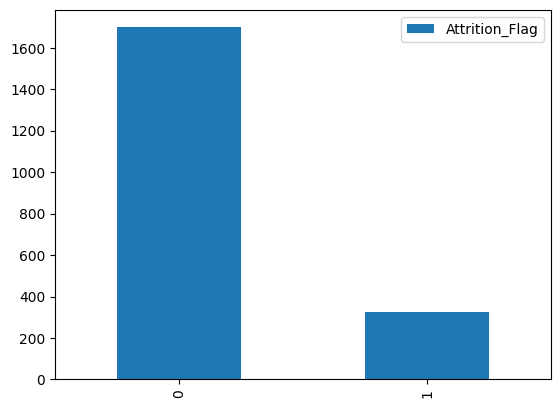

In [ ]:
#### Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar', legend=True)

Based on the graph, there are a lot of customers who stay with the company, and there are a few customers who left the company. The outcome of the data is positive because the company is doing an excellent job of retaining customers. I recommend conducting regular customer satisfaction surveys to understand why customers stay with the company and what could be improved.

### Customer_Age vs Attrition_Flag

In [ ]:
#### Get mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age']

Attrition_Flag
0    46.579164
1    45.495413
Name: Customer_Age, dtype: float64

<Axes: xlabel='Attrition_Flag'>

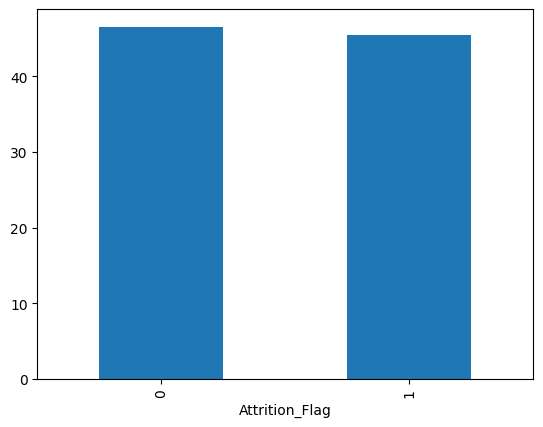

In [ ]:
#### Plot mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age'].plot(kind='bar')

Customers who left the company (attrition flag of 1) tend to be younger than customers who stayed (attrition flag of 0). The comparison between the average age of customers who remain and those who left the company is almost exactly the same. My recommendation is to conduct further analysis to identify other factors that are correlated with customer churn.

Attrition_Flag
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: Customer_Age, dtype: object

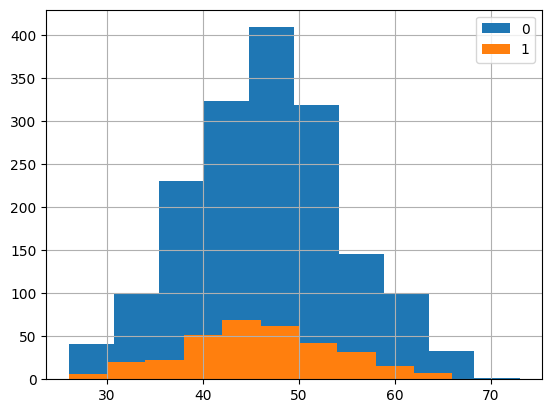

In [ ]:
#### Plot histogram of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag')['Customer_Age'].hist(legend=True)

Based on the plot histogram, the customer age distribution is similar for customers who stayed (attrition flag 0) and customers who left (attrition flag 1). Both groups have a higher concentration of customers in their 30s and 40s, with a gradual decline in the number of customers as age increases. More customers stayed with the company than customers who left, regardless of age group. I have two questions for this scenario: Are there other factors the company is considering when reducing customer churn? What are the company's current customer churn reduction strategies?

### Dependent_count vs Attrition_Flag

In [ ]:
#### Get mean Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Dependent_count']

Attrition_Flag
0    2.384344
1    2.431193
Name: Dependent_count, dtype: float64

<Axes: xlabel='Attrition_Flag'>

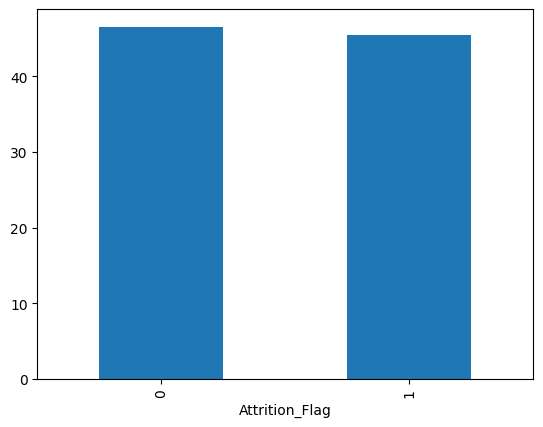

In [ ]:
#### Plot mean Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age'].plot(kind='bar')

It shows that there is a slight difference between the customer's ages who stayed and those who left. However, when it comes to their average dependent count, the customers who stayed have an average of 2.38, and those who left have an average of 2.43. This means that the customers who left the company have a more dependent count than those who stayed.

Attrition_Flag
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: Dependent_count, dtype: object

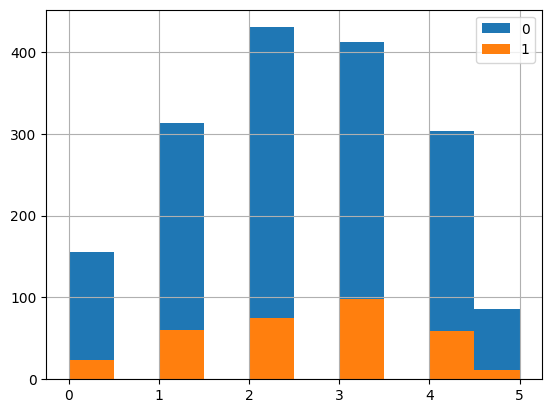

In [ ]:
#### Plot histogram of Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag')['Dependent_count'].hist(legend=True)

The distribution of the number of supplementary cards is similar for both groups, with a peak of around 2-3 supplementary cards and a gradual decline on either side. There are more customers who stayed with the company than customers who left, regardless of the number of supplementary cards. Also, investigate the reasons why customers with more dependents might be more likely to leave. Are there specific needs or challenges that this group faces that the company can address?

### Months_Inactive_12_mon vs Attrition_Flag

In [ ]:
#### Get mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon']

Attrition_Flag
0    2.258976
1    2.626911
Name: Months_Inactive_12_mon, dtype: float64

<Axes: xlabel='Attrition_Flag'>

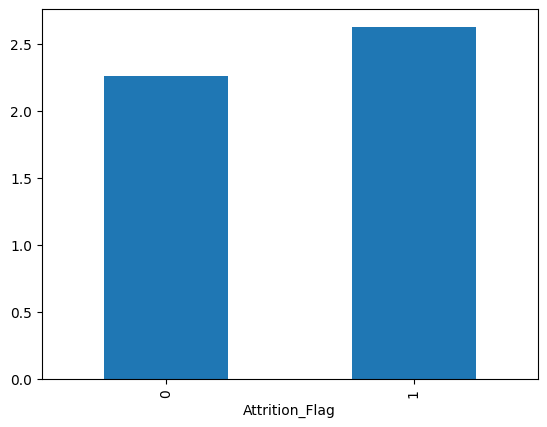

In [ ]:
#### Plot mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon'].plot(kind='bar')

Customers who left the company (attrition flag 1) tend to be inactive for longer than those who stayed (attrition flag 0), and customers who left the company show a steeper increase in inactivity duration, indicating a more decisive shift away from using the product. I think they should implement a system to monitor customer activity and identify customers who are becoming inactive.

### Credit_Limit vs Attrition_Flag

In [ ]:
#### Get mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit']

Attrition_Flag
0    8699.889935
1    8165.156575
Name: Credit_Limit, dtype: float64

<Axes: xlabel='Attrition_Flag'>

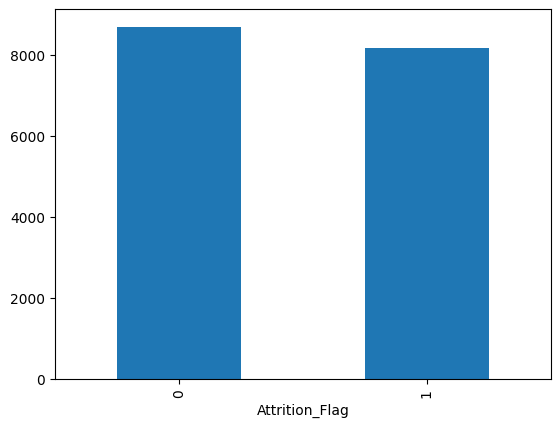

In [ ]:
#### Plot mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit'].plot(kind='bar')

Based on the plot, it shows that there is a slight difference in the average credit limit between customers who stayed (attrition flag 0) and those who left (attrition flag 1). Customers who stayed have a slightly higher average credit limit (8699.89) compared to those who left (8165.16). While there is a difference, it's relatively small and might not be statistically significant. In this case, credit limit alone may not be a strong indicator of customer churn.

### Total_Trans_Amt vs Attrition_Flag

In [ ]:
#### Get mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt']

Attrition_Flag
0    4601.972925
1    3403.128440
Name: Total_Trans_Amt, dtype: float64

<Axes: xlabel='Attrition_Flag'>

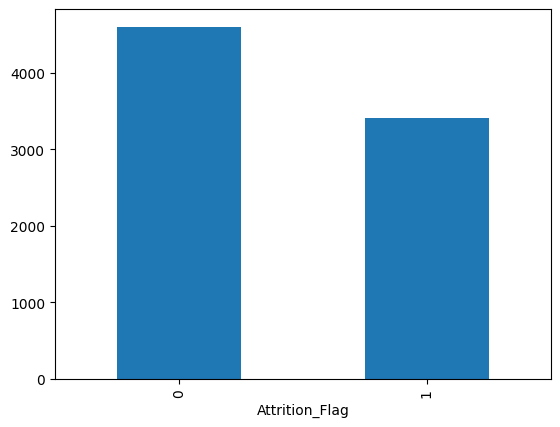

In [ ]:
#### Plot mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt'].plot(kind='bar')

Based on the plot, customers who left the company (attrition flag 1) tend to have a lower average total transaction amount than those who stayed (attrition flag 0). This suggests that customers spending less money with the company are likelier to churn. The transaction amount could be a valuable indicator for predicting customer churn. I also recommend to offer some incentives or rewards to customers who increase their total transaction amount, such as discounts, loyalty points, or exclusive benefits, to encourage them to spend more and to retain the customers.
